# MNIST Digit Classification: Neural Network Hyperparameter Study

A systematic comparison of feedforward neural network configurations on the MNIST handwritten digit dataset.
Two activation functions (ReLU and Tanh) are evaluated across a range of hyperparameters:

- **Optimizers:** SGD vs. Adam
- **Learning rates:** 0.01 vs. 0.001
- **Batch sizes:** 32 vs. 64
- **Regularization:** L2, early stopping, and their combination

Each variable is tested independently to observe its isolated effect on training stability, validation accuracy, and overfitting.

## 1. Load Dataset

In [1]:
# import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Input
from tensorflow.keras import regularizers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

/Users/michelle/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Set random seeds for reproducibility
import random
import os
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [3]:
# load dataset and split into testing and training sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
# print shapes
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


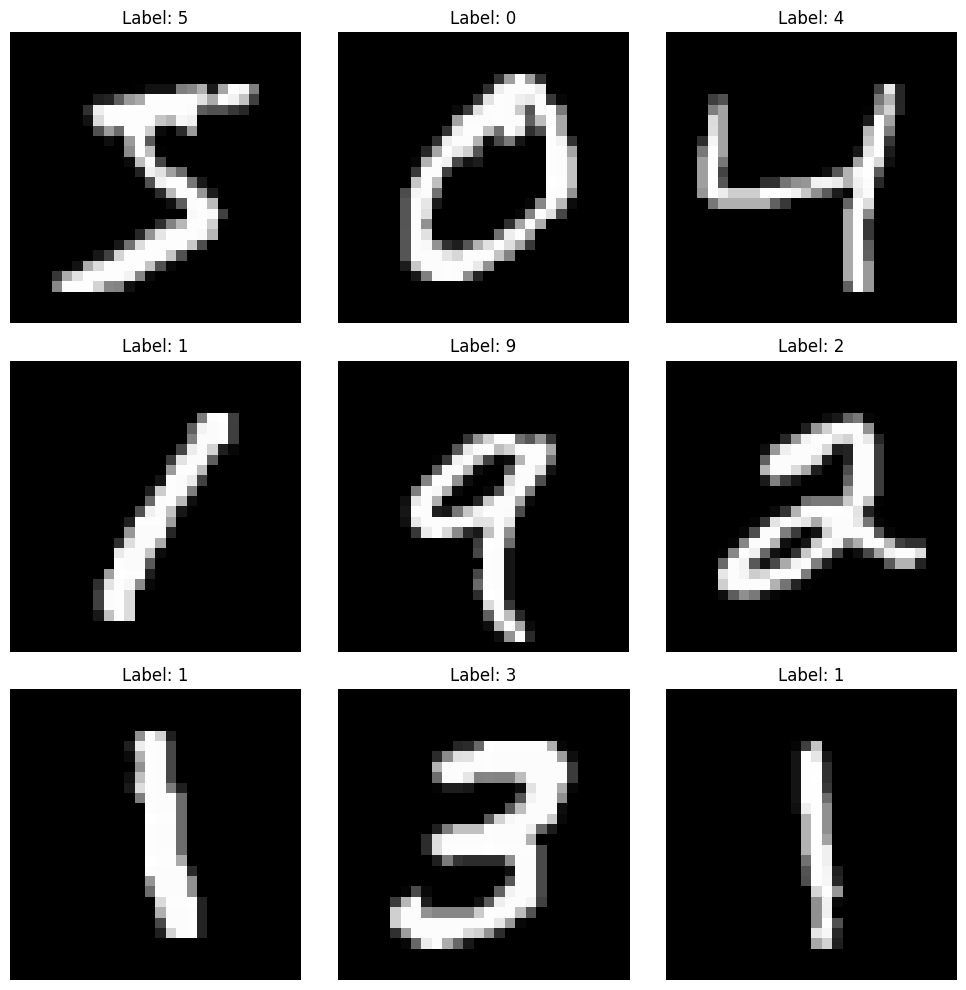

In [5]:
# display the first 9 digits
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Preprocessing data

In [6]:
# normalize values to range 0 - 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# flatten images from 2d to 1d vector
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# one-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Flattened training data shape:", x_train_flat.shape)
print("Flattened test data shape:", x_test_flat.shape)

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


## 3. Helper functions

In [7]:
# build base model function
def build_model(activation='relu'):
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(32, activation=activation),
        Dense(10, activation='softmax')
    ])
    return model

In [8]:
# build model with regularization function
def build_model_regularization(activation='relu', use_l2=False, l2_rate=0.01, use_dropout=False, dropout_rate=0.1):
    regularizer = l2(l2_rate) if use_l2 else None

    model = Sequential()
    model.add(Input(shape=(784,)))
    model.add(Dense(128, activation=activation, kernel_regularizer=regularizer))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation=activation, kernel_regularizer=regularizer))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation=activation, kernel_regularizer=regularizer))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    return model

In [9]:
# train model function
def train_model(activation='relu', optimizer=SGD, momentum=0.90, lr=0.01, epochs=10, batch_size=32, earlystop=False, use_l2=False, l2_rate=0.01, use_dropout=False, dropout_rate=0.1):
    
    if not use_l2 and not use_dropout:
        model = build_model(activation=activation)
    else:
        model = build_model_regularization(
            activation=activation,
            use_l2=use_l2,
            l2_rate=l2_rate,
            use_dropout=use_dropout,
            dropout_rate=dropout_rate
        )

    if optimizer == SGD:
        opt = SGD(learning_rate=lr, momentum=momentum)
    else: 
        opt = Adam(learning_rate=lr)

    callbacks = []
    if earlystop:
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        callbacks.append(early_stop)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        x_train_flat, y_train_cat,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history

In [10]:
# plot function
def plot_base_comparison(history_r_sgd, history_r_adam, history_t_sgd, history_t_adam):
    
    plt.figure(figsize=(14, 10))

    # --- ReLU Accuracy ---
    plt.subplot(2, 2, 1)
    plt.plot(history_r_sgd['accuracy'], label='SGD Train', linestyle='-', color='blue')
    plt.plot(history_r_sgd['val_accuracy'], label='SGD Val', linestyle='--', color='blue')
    plt.plot(history_r_adam['accuracy'], label='Adam Train', linestyle='-', color='green')
    plt.plot(history_r_adam['val_accuracy'], label='Adam Val', linestyle='--', color='green')
    plt.title('ReLU - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.yticks(np.arange(0.75, 1, 0.05))
    plt.grid(True)

    # --- Tanh Accuracy ---
    plt.subplot(2, 2, 2)
    plt.plot(history_t_sgd['accuracy'], label='SGD Train', linestyle='-', color='blue')
    plt.plot(history_t_sgd['val_accuracy'], label='SGD Val', linestyle='--', color='blue')
    plt.plot(history_t_adam['accuracy'], label='Adam Train', linestyle='-', color='green')
    plt.plot(history_t_adam['val_accuracy'], label='Adam Val', linestyle='--', color='green')
    plt.title('Tanh - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.yticks(np.arange(0.75, 1, 0.05))
    plt.grid(True)

    # --- ReLU Loss ---
    plt.subplot(2, 2, 3)
    plt.plot(history_r_sgd['loss'], label='SGD Train', linestyle='-', color='blue')
    plt.plot(history_r_sgd['val_loss'], label='SGD Val', linestyle='--', color='blue')
    plt.plot(history_r_adam['loss'], label='Adam Train', linestyle='-', color='green')
    plt.plot(history_r_adam['val_loss'], label='Adam Val', linestyle='--', color='green')
    plt.title('ReLU - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.yticks(np.arange(0, 0.45, 0.05))
    plt.grid(True)

    # --- Tanh Loss ---
    plt.subplot(2, 2, 4)
    plt.plot(history_t_sgd['loss'], label='SGD Train', linestyle='-', color='blue')
    plt.plot(history_t_sgd['val_loss'], label='SGD Val', linestyle='--', color='blue')
    plt.plot(history_t_adam['loss'], label='Adam Train', linestyle='-', color='green')
    plt.plot(history_t_adam['val_loss'], label='Adam Val', linestyle='--', color='green')
    plt.title('Tanh - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.yticks(np.arange(0, 0.45, 0.05))
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
# plot comparison function
def plot_model_comparison(
    results_base: dict,
    results_test: dict,
    model_names: list,
    metric_title: str = "Train vs Validation Metrics"
):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(metric_title, fontsize=16)

    for i, model_name in enumerate(model_names):
        row = 0
        col = i

        # Accuracy subplot
        axs[row, col].plot(results_base[model_name]['accuracy'], label='Train Acc (base)', color='red')
        axs[row, col].plot(results_base[model_name]['val_accuracy'], label='Val Acc (base)', linestyle='--', color='red')
        axs[row, col].plot(results_test[model_name]['accuracy'], label='Train Acc (test)', color='orange')
        axs[row, col].plot(results_test[model_name]['val_accuracy'], label='Val Acc (test)', linestyle='--', color='orange')
        axs[row, col].set_title(f"{model_name} - Accuracy")
        axs[row, col].set_xlabel("Epoch")
        axs[row, col].set_ylabel("Accuracy")
        axs[row, col].legend()
        axs[row, col].grid(True)

        # Loss subplot
        row = 1
        axs[row, col].plot(results_base[model_name]['loss'], label='Train Loss (base)', color='red')
        axs[row, col].plot(results_base[model_name]['val_loss'], label='Val Loss (base)', linestyle='--', color='red')
        axs[row, col].plot(results_test[model_name]['loss'], label='Train Loss (test)', color='orange')
        axs[row, col].plot(results_test[model_name]['val_loss'], label='Val Loss (test)', linestyle='--', color='orange')
        axs[row, col].set_title(f"{model_name} - Loss")
        axs[row, col].set_xlabel("Epoch")
        axs[row, col].set_ylabel("Loss")
        axs[row, col].legend()
        axs[row, col].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## 4. Baseline models
Compare optimizers: SGD, Adam

### 4.1 ReLU

In [12]:
# ReLU
print('act=ReLU, opt=SGD')
history_r_sgd_base = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32)

print('\nact=ReLU, opt=Adam')
history_r_adam_base = train_model(activation='relu', optimizer=Adam, lr=0.01, epochs=10, batch_size=32)

act=ReLU, opt=SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - accuracy: 0.8048 - loss: 0.6164 - val_accuracy: 0.9527 - val_loss: 0.1564
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - accuracy: 0.9564 - loss: 0.1432 - val_accuracy: 0.9628 - val_loss: 0.1302
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - accuracy: 0.9713 - loss: 0.0953 - val_accuracy: 0.9648 - val_loss: 0.1254
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.9783 - loss: 0.0702 - val_accuracy: 0.9630 - val_loss: 0.1325
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9831 - loss: 0.0544 - val_accuracy: 0.9615 - val_loss: 0.1433
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9682 - val_loss: 0.1282
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.9861 - loss: 0.0412 - val_accuracy: 0.9697 - val_loss: 0.1275
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - 

### 4.2 Tanh

In [13]:
# Tanh

print('act=Tanh, opt=SGD')
history_t_sgd_base = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32)

print('\nact=Tanh, opt=Adam')
history_t_adam_base = train_model(activation='tanh', optimizer=Adam, lr=0.01, epochs=10, batch_size=32)

act=Tanh, opt=SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 858us/step - accuracy: 0.8401 - loss: 0.5592 - val_accuracy: 0.9426 - val_loss: 0.1955
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - accuracy: 0.9486 - loss: 0.1708 - val_accuracy: 0.9618 - val_loss: 0.1348
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.9655 - loss: 0.1140 - val_accuracy: 0.9659 - val_loss: 0.1179
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.9742 - loss: 0.0856 - val_accuracy: 0.9690 - val_loss: 0.1090
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9804 - loss: 0.0669 - val_accuracy: 0.9706 - val_loss: 0.0994
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.9856 - loss: 0.0521 - val_accuracy: 0.9717 - val_loss: 0.0976
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9896 - loss: 0.0400 - val_accuracy: 0.9715 - val_loss: 0.1006
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - 

### 4.3 Plot: Compare ReLU vs Tanh  by Optimizers

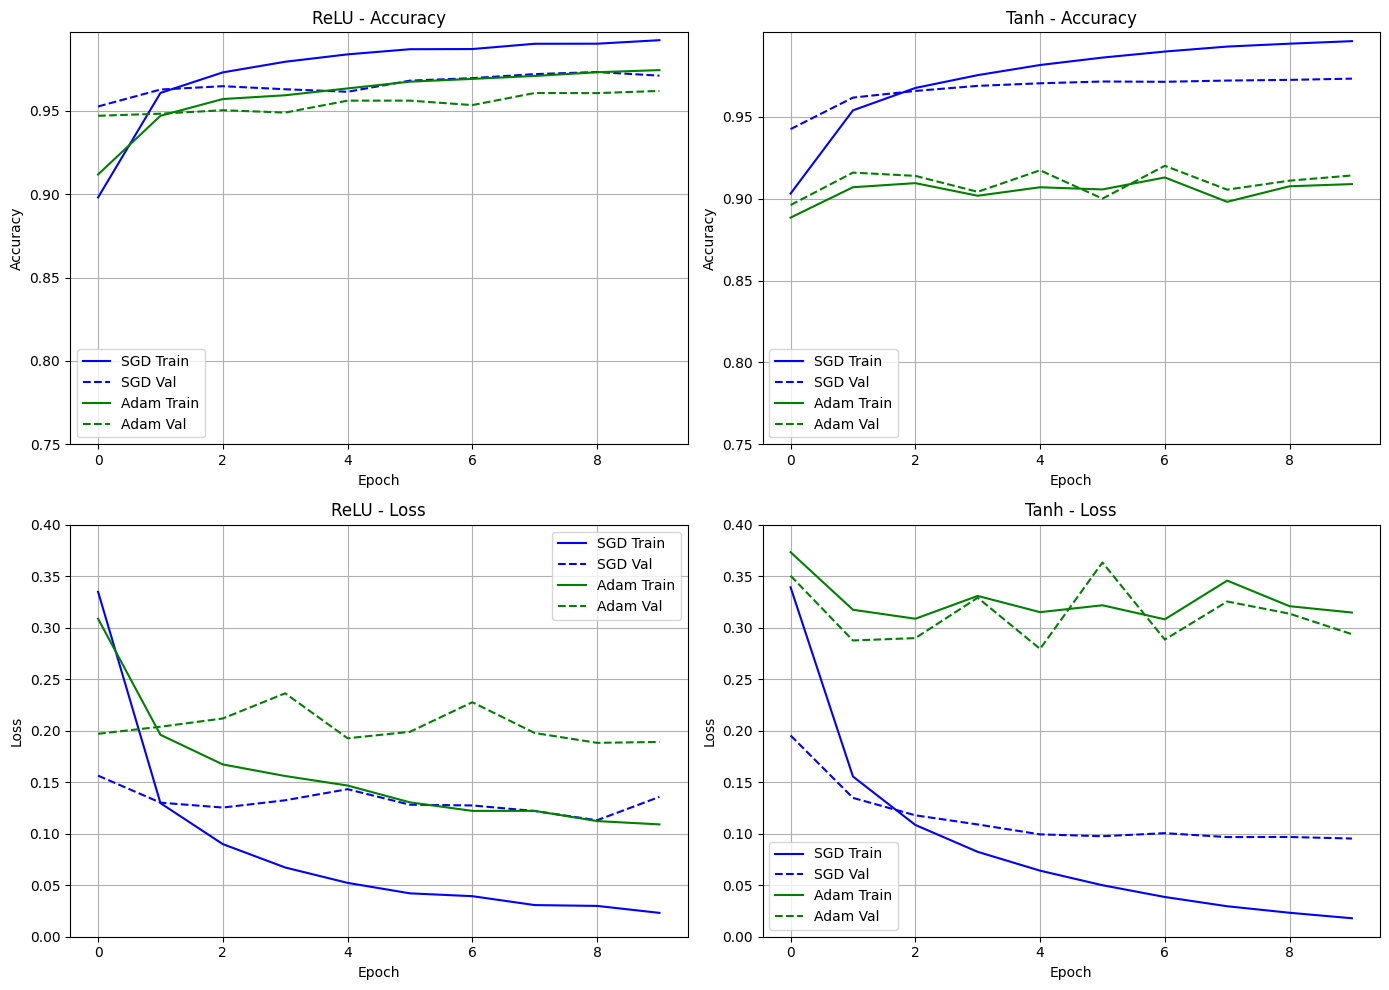

In [14]:
results_base_r = {
    'ReLU + SGD': history_r_sgd_base.history,
    'ReLU + Adam': history_r_adam_base.history,
}

results_base_t = {
    'Tanh + SGD': history_t_sgd_base.history,
    'Tanh + Adam': history_t_adam_base.history,
}

plot_base_comparison(
    history_r_sgd_base.history,
    history_r_adam_base.history,
    history_t_sgd_base.history,
    history_t_adam_base.history
)

### 4.4 Notes

#### ReLU

ReLU + SGD
- Training accuracy consistently increases reaching 0.9943 by epoch 10.
- Validation accuracy reaches 0.9730 at epoch 10, but decreases from epochs 6-9 (overfitting)
- Validation loss lowest near 0.0971 at epoch 6, then increases (overfitting)
- End validation loss = 0.1108

ReLU + Adam
- Faster initial training accuracy (0.8633 at epoch 1) but slower improvement than SGD.
- Validation accuracy reaches 0.9658 at epoch 10, but decreases at epoch 5 and 7-9 (overfitting)
- Validation loss increases at epoch 5-10
- End validation loss = 0.2115

#### Tanh

Tanh + SGD
- Training acc consistently icncreases, reaching 0.9936 at epoch 10
- Validation acc consistently increases ending at epoch 10 at 0.9759 
- Validation loss increases at epoch 8, but reaches 0.0898 by epoch 10 (overfitting)
- End validation loss = 0.0898 - best val loss

Tanh + Adam
- Slower and unstable training progression, training acc decreases at epoch 7 and final value = 0.9031
- Training loss increases
- Validation acc spikes throughout the epochs, ending at epoch 10 with 0.9172 (overfitting)
- Validation loss also spikes (overfitting)
- End validation loss = 0.2918

#### Overall

- SGD outperforms Adam for both models, showing more stable and higher accuracy with both activations. 
- Tanh + SGD yields slightly better validation loss and accuracy than ReLU + SGD.
- Adam performs well with ReLU but poorly with Tanh.

## 5. Adjust learning rates
Compare learning rates: 0.01, 0.001

### 5.1 Test Relu models with lr=0.001

In [15]:
# ReLU

print('act=ReLU, opt=SGD, learning rate=0.001')
history_r_sgd_lr = train_model(activation='relu', optimizer=SGD,  momentum=0.9, lr=0.001, epochs=10, batch_size=32)

print('\nact=ReLU, opt=Adam, learning rate=0.001')
history_r_adam_lr = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=32)

act=ReLU, opt=SGD, learning rate=0.001
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - accuracy: 0.6093 - loss: 1.2914 - val_accuracy: 0.9097 - val_loss: 0.3169
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.9093 - loss: 0.3168 - val_accuracy: 0.9300 - val_loss: 0.2443
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9298 - loss: 0.2433 - val_accuracy: 0.9434 - val_loss: 0.2033
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - accuracy: 0.9419 - loss: 0.1975 - val_accuracy: 0.9503 - val_loss: 0.1772
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9507 - loss: 0.1654 - val_accuracy: 0.9545 - val_loss: 0.1599
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.9579 - loss: 0.1424 - val_accuracy: 0.9573 - val_loss: 0.1478
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9641 - loss: 0.1248 - val_accuracy: 0.9600 - val_loss: 0.1381
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━

#### 5.1.1 Plot: Compare Relu Learning Rates (0.01 v 0.001) by Optimizers

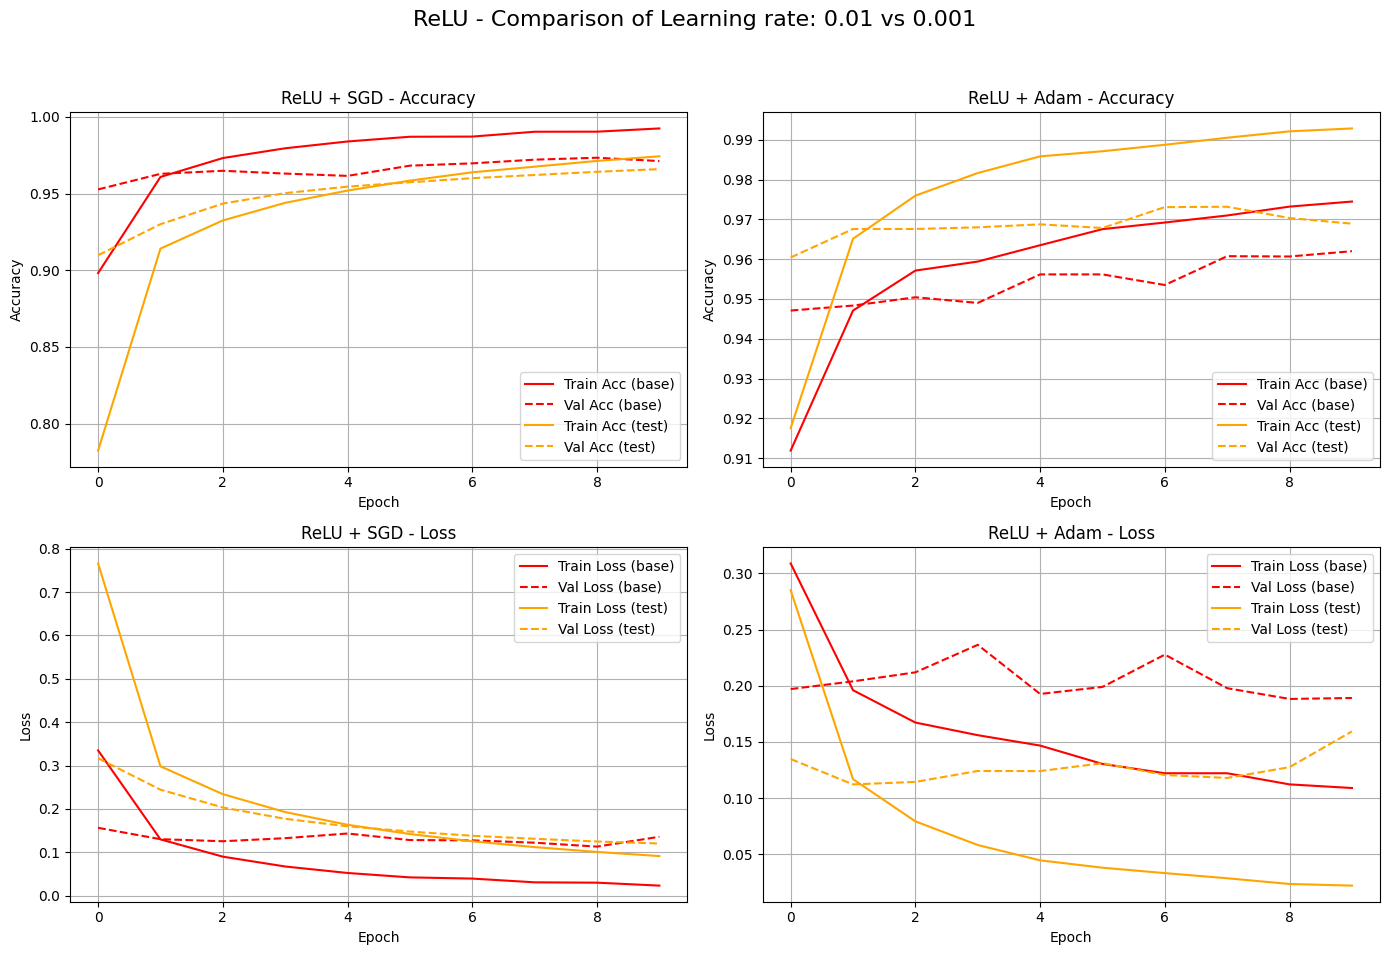

In [16]:
results_r_lr = {
    'ReLU + SGD': history_r_sgd_lr.history,
    'ReLU + Adam': history_r_adam_lr.history,
}

plot_model_comparison(
    results_base=results_base_r,
    results_test=results_r_lr,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="ReLU - Comparison of Learning rate: 0.01 vs 0.001"
)

#### 5.1.2 Notes

ReLU + SGD
- SGD with 0.01 LR yields fastest training accuracy and high validation accuracy but can have slight fluctuations in val loss.
- Lowering LR to 0.001 slows down SGD training but improves stability and maintains good val accuracy.

ReLU + Adam
- Adam at 0.01 LR trains less stably with higher loss and slightly lower validation accuracy.
- Adam with 0.001 LR shows the best balance: fast, stable training with high validation accuracy and low loss.


### 5.2 Test Tanh models with lr=0.001

In [17]:
# Tanh

print('act=Tanh, opt=SGD, learning rate=0.001')
history_t_sgd_lr = train_model(activation='tanh', optimizer=SGD,  momentum=0.9, lr=0.001, epochs=10, batch_size=32)

print('\nact=Tanh, opt=Adam, learning rate=0.001')
history_t_adam_lr = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=10, batch_size=32)

act=Tanh, opt=SGD, learning rate=0.001
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.7127 - loss: 1.0942 - val_accuracy: 0.9036 - val_loss: 0.3762
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9021 - loss: 0.3650 - val_accuracy: 0.9212 - val_loss: 0.2881
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.9194 - loss: 0.2889 - val_accuracy: 0.9305 - val_loss: 0.2486
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9289 - loss: 0.2489 - val_accuracy: 0.9376 - val_loss: 0.2224
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9373 - loss: 0.2204 - val_accuracy: 0.9427 - val_loss: 0.2024
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - accuracy: 0.9439 - loss: 0.1978 - val_accuracy: 0.9477 - val_loss: 0.1866
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9489 - loss: 0.1792 - val_accuracy: 0.9513 - val_loss: 0.1738
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━

#### 5.2.1 Plot: Compare Tanh Learning Rates (0.01 v 0.001) by Optimizers

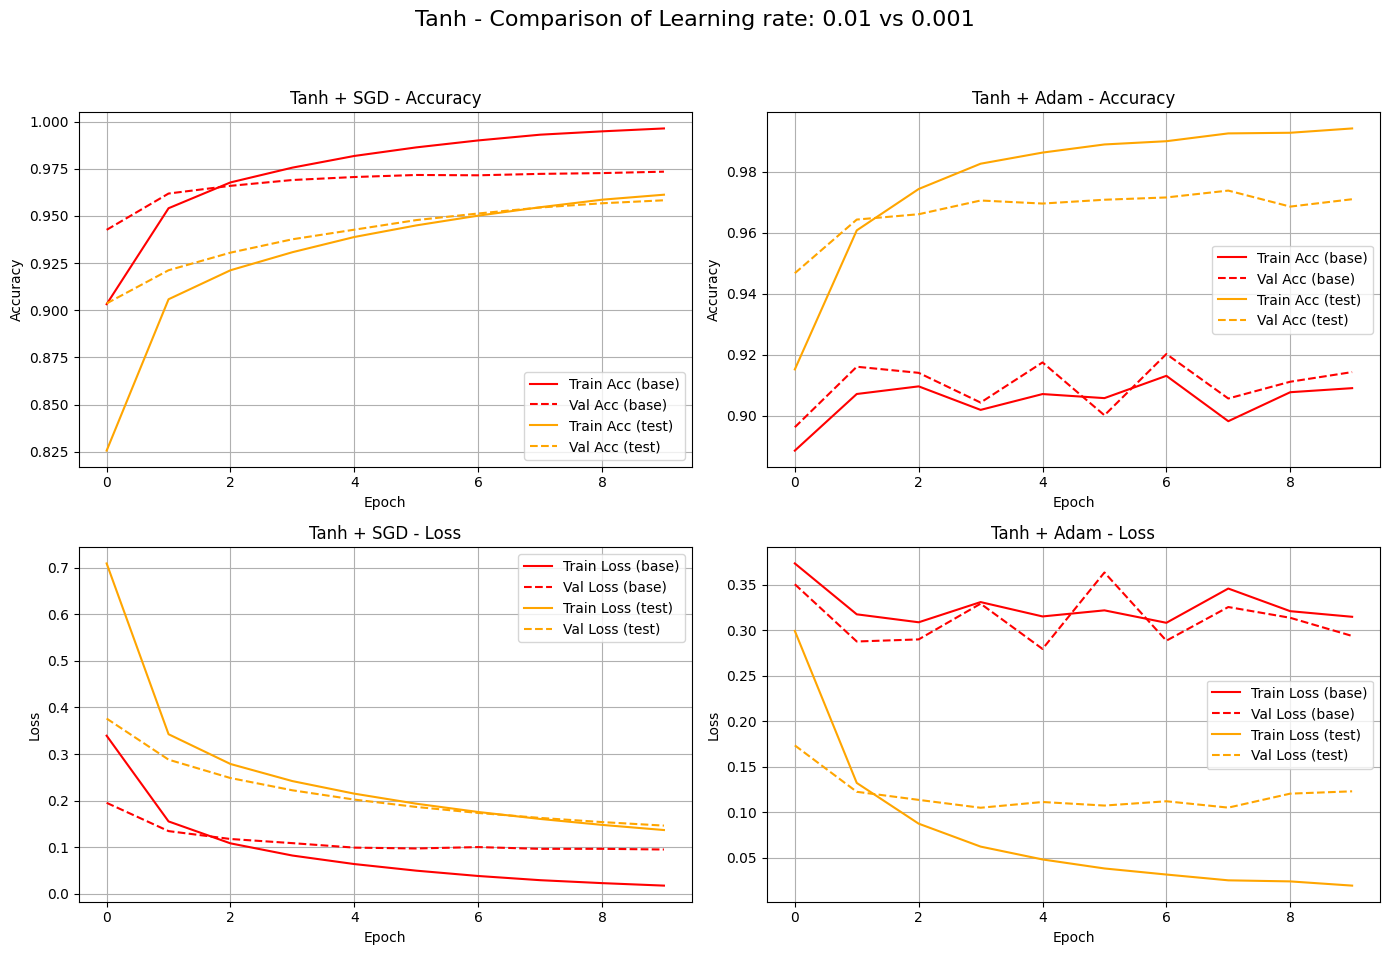

In [18]:
results_t_lr = {
    'Tanh + SGD': history_t_sgd_lr.history,
    'Tanh + Adam': history_t_adam_lr.history,
}

plot_model_comparison(
    results_base=results_base_t,
    results_test=results_t_lr,
    model_names=['Tanh + SGD', 'Tanh + Adam'],
    metric_title="Tanh - Comparison of Learning rate: 0.01 vs 0.001"
)

#### 5.2.2 Notes

Tanh + SGD
- SGD at lr=0.01 outperforms SGD at lr=0.001 in both accuracy and loss; faster convergence.


Tanh + Adam
- Adam at lr=0.001 is far superior to Adam at lr=0.01, achieving very high accuracy and low loss.
- Adam optimizer performs poorly with Tanh at higher lr (0.01), showing unstable training and low accuracy.

### 5.3 Update Base Models

Both ReLU and Tanh models:
- SGD will continue to use learning_rate=0.01
- Adam will use learning_rate=0.001

In [19]:
# ReLU
print('act=ReLU, opt=SGD, lr=0.01')
history_r_sgd_updated = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32)

print('\nact=ReLU, opt=Adam, lr=0.001')
history_r_adam_updated = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=32)

act=ReLU, opt=SGD, lr=0.01
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - accuracy: 0.8175 - loss: 0.5835 - val_accuracy: 0.9579 - val_loss: 0.1471
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9572 - loss: 0.1387 - val_accuracy: 0.9653 - val_loss: 0.1210
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.9726 - loss: 0.0910 - val_accuracy: 0.9657 - val_loss: 0.1200
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.9784 - loss: 0.0697 - val_accuracy: 0.9672 - val_loss: 0.1229
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.9817 - loss: 0.0555 - val_accuracy: 0.9671 - val_loss: 0.1250
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - accuracy: 0.9855 - loss: 0.0442 - val_accuracy: 0.9720 - val_loss: 0.1108
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step - accuracy: 0.9876 - loss: 0.0368 - val_accuracy: 0.9738 - val_loss: 0.1122
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 764u

In [20]:
# Tanh
print('act=Tanh, opt=SGD, lr=0.01')
history_t_sgd_updated = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32)

print('\nact=Tanh, opt=Adam, lr=0.001')
history_t_adam_updated = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=10, batch_size=32)

act=Tanh, opt=SGD, lr=0.01
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - accuracy: 0.8423 - loss: 0.5375 - val_accuracy: 0.9487 - val_loss: 0.1808
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.9500 - loss: 0.1665 - val_accuracy: 0.9622 - val_loss: 0.1342
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.9669 - loss: 0.1131 - val_accuracy: 0.9638 - val_loss: 0.1201
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - accuracy: 0.9751 - loss: 0.0839 - val_accuracy: 0.9660 - val_loss: 0.1137
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.9822 - loss: 0.0639 - val_accuracy: 0.9693 - val_loss: 0.1066
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - accuracy: 0.9866 - loss: 0.0492 - val_accuracy: 0.9706 - val_loss: 0.1037
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.9900 - loss: 0.0383 - val_accuracy: 0.9703 - val_loss: 0.1073
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 815u

### 5.4 Plot - Compare ReLU vs Tanh by Optimizers 

Now with updated Adam learning_rate=0.001

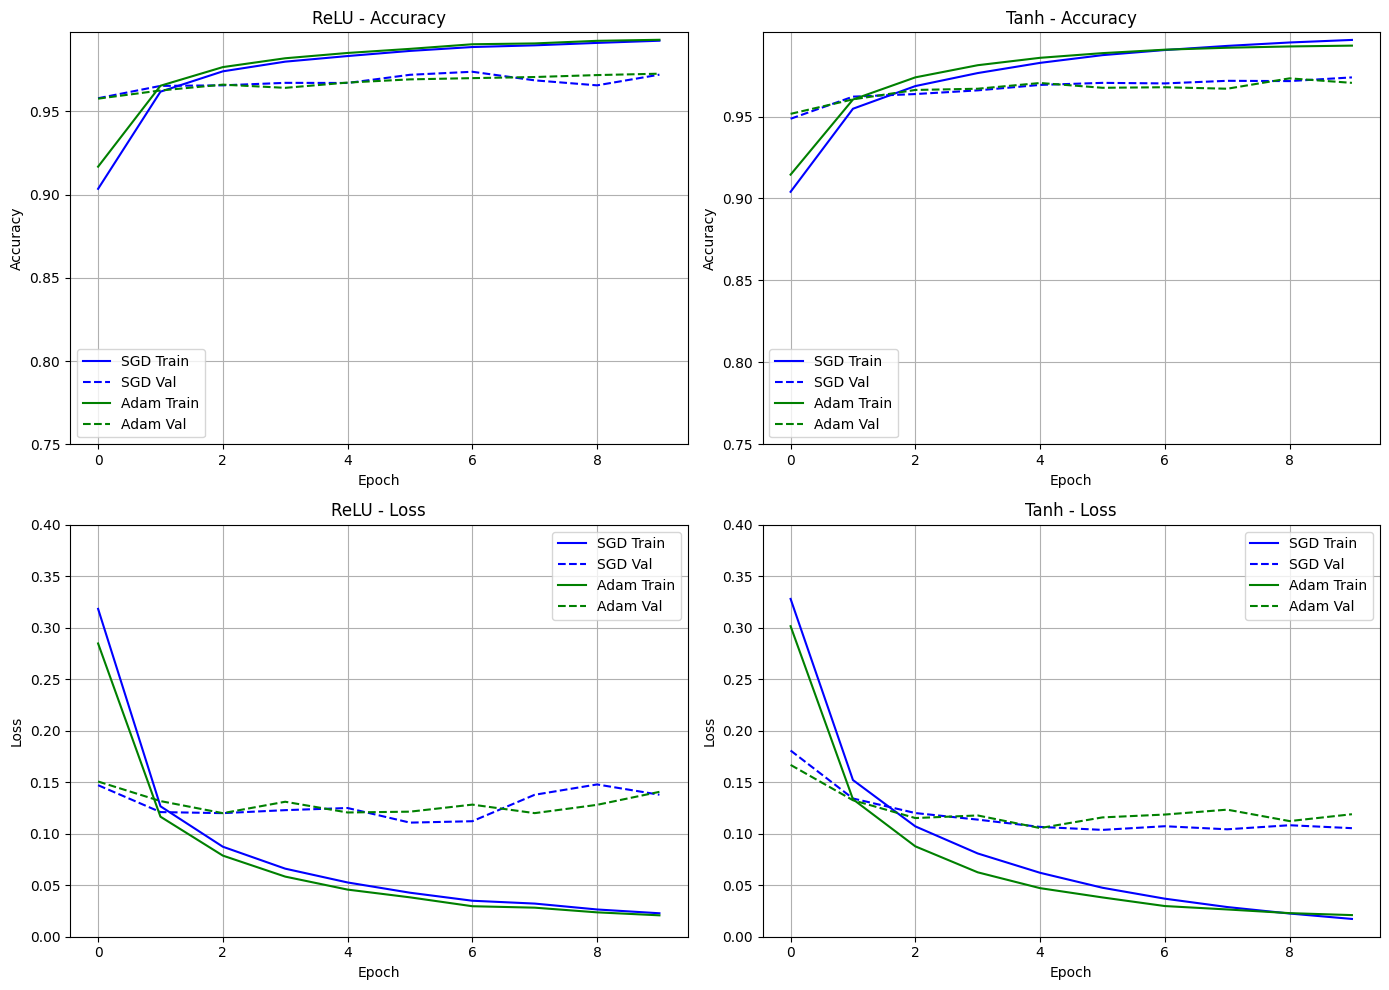

In [21]:
results_r_updated = {
    'ReLU + SGD': history_r_sgd_updated.history,
    'ReLU + Adam': history_r_adam_updated.history,
}

results_t_updated = {
    'Tanh + SGD': history_t_sgd_updated.history,
    'Tanh + Adam': history_t_adam_updated.history,
}

plot_base_comparison(
    history_r_sgd_updated.history,
    history_r_adam_updated.history,
    history_t_sgd_updated.history,
    history_t_adam_updated.history
)

## 6. Adjust batch size
Compare batch sizes: 32, 64

### 6.1 Update ReLU models with batch_size=64

In [22]:
# ReLU
print('act=ReLU, opt=SGD, bs=64')
history_r_sgd_bs = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=64)

print('\nact=ReLU, opt=Adam, bs=64')
history_r_adam_bs = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=64)

act=ReLU, opt=SGD, bs=64
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7305 - loss: 0.8411 - val_accuracy: 0.9450 - val_loss: 0.1905
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 907us/step - accuracy: 0.9453 - loss: 0.1796 - val_accuracy: 0.9557 - val_loss: 0.1502
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.9618 - loss: 0.1231 - val_accuracy: 0.9628 - val_loss: 0.1264
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step - accuracy: 0.9716 - loss: 0.0927 - val_accuracy: 0.9645 - val_loss: 0.1194
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 896us/step - accuracy: 0.9786 - loss: 0.0710 - val_accuracy: 0.9682 - val_loss: 0.1117
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9831 - loss: 0.0569 - val_accuracy: 0.9704 - val_loss: 0.1029
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step - accuracy: 0.9861 - loss: 0.0471 - val_accuracy: 0.9712 - val_loss: 0.1059
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0

#### 6.1.1 Plot: Compare ReLU Batch Sizes (32, 64) by Optimizers

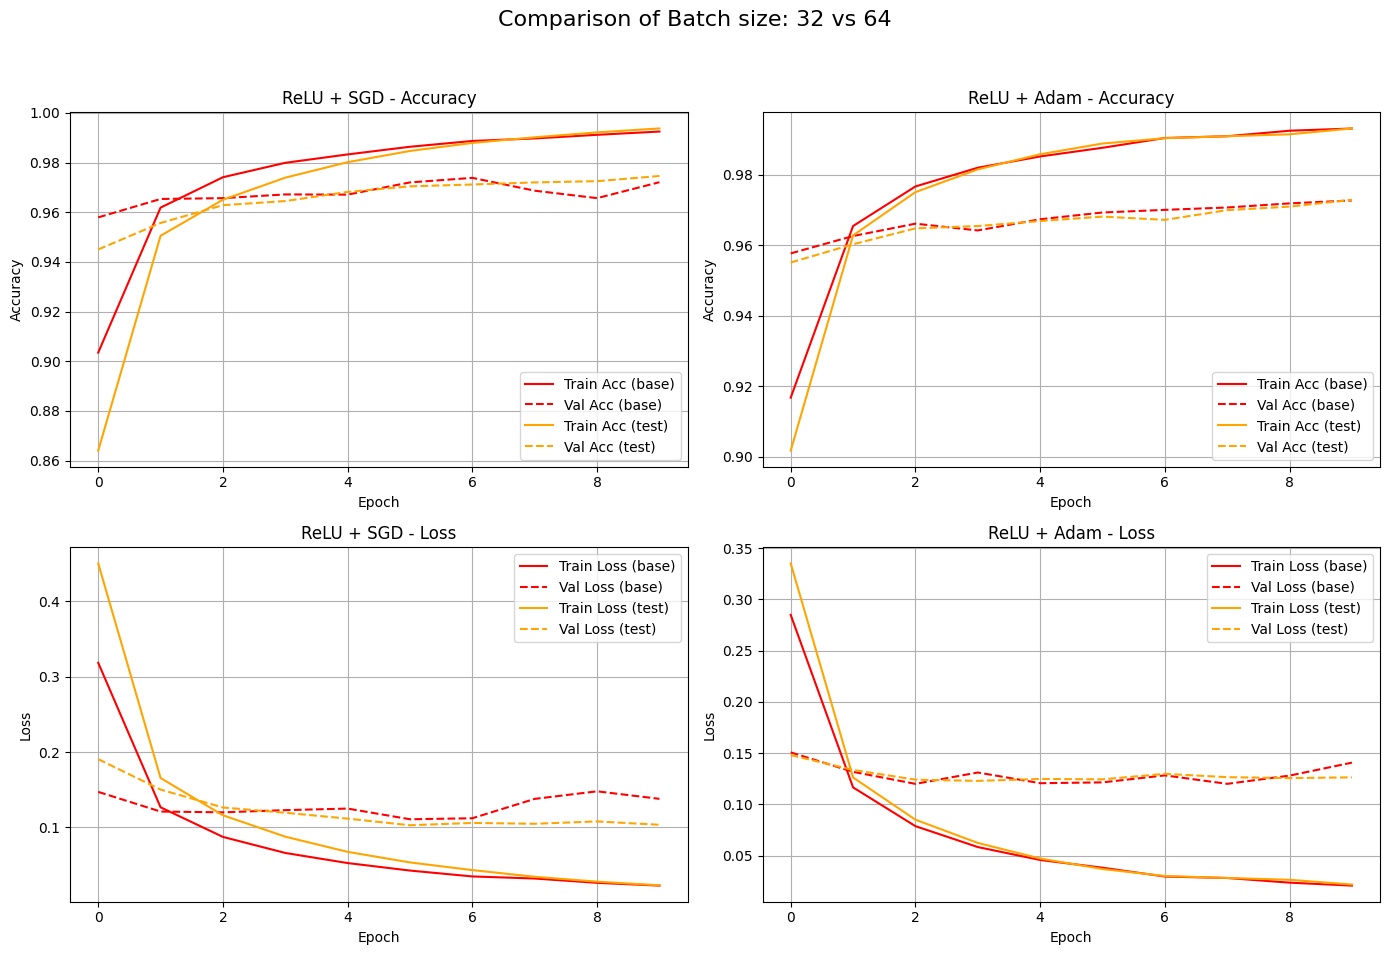

In [23]:
results_r_adjusted_bs = {
    'ReLU + SGD': history_r_sgd_bs.history,
    'ReLU + Adam': history_r_adam_bs.history,
}

plot_model_comparison(
    results_base=results_r_updated,
    results_test=results_r_adjusted_bs,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="Comparison of Batch size: 32 vs 64"
)

#### 6.1.2 Notes

ReLU + SGD
- Batch=64 appears to have better final train/val acc and loss than batch=32
- Going forward will continue to use batch=64 for SGD

ReLU + Adam
- Batch=32 has better train acc, however worse val acc than batch=64
- Batch=64 converges faster and has best val acc
- Going forward will use batch=64 for Adam



### 6.2 Update Tanh models with batch_size=64

In [24]:
# Tanh
print('act=Tanh, opt=SGD, bs=64')
history_t_sgd_bs = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=64)

print('\nact=Tanh, opt=Adam, bs=64')
history_t_adam_bs = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=10, batch_size=64)

act=Tanh, opt=SGD, bs=64
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8128 - loss: 0.6722 - val_accuracy: 0.9345 - val_loss: 0.2238
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.9381 - loss: 0.2097 - val_accuracy: 0.9510 - val_loss: 0.1666
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.9549 - loss: 0.1485 - val_accuracy: 0.9582 - val_loss: 0.1407
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step - accuracy: 0.9651 - loss: 0.1148 - val_accuracy: 0.9624 - val_loss: 0.1265
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9719 - loss: 0.0924 - val_accuracy: 0.9653 - val_loss: 0.1173
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.9776 - loss: 0.0763 - val_accuracy: 0.9665 - val_loss: 0.1126
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9814 - loss: 0.0639 - val_accuracy: 0.9667 - val_loss: 0.1111
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 927us/step - accuracy:

#### 6.2.1 Plot: Compare ReLU Batch Sizes (32, 64) by Optimizers

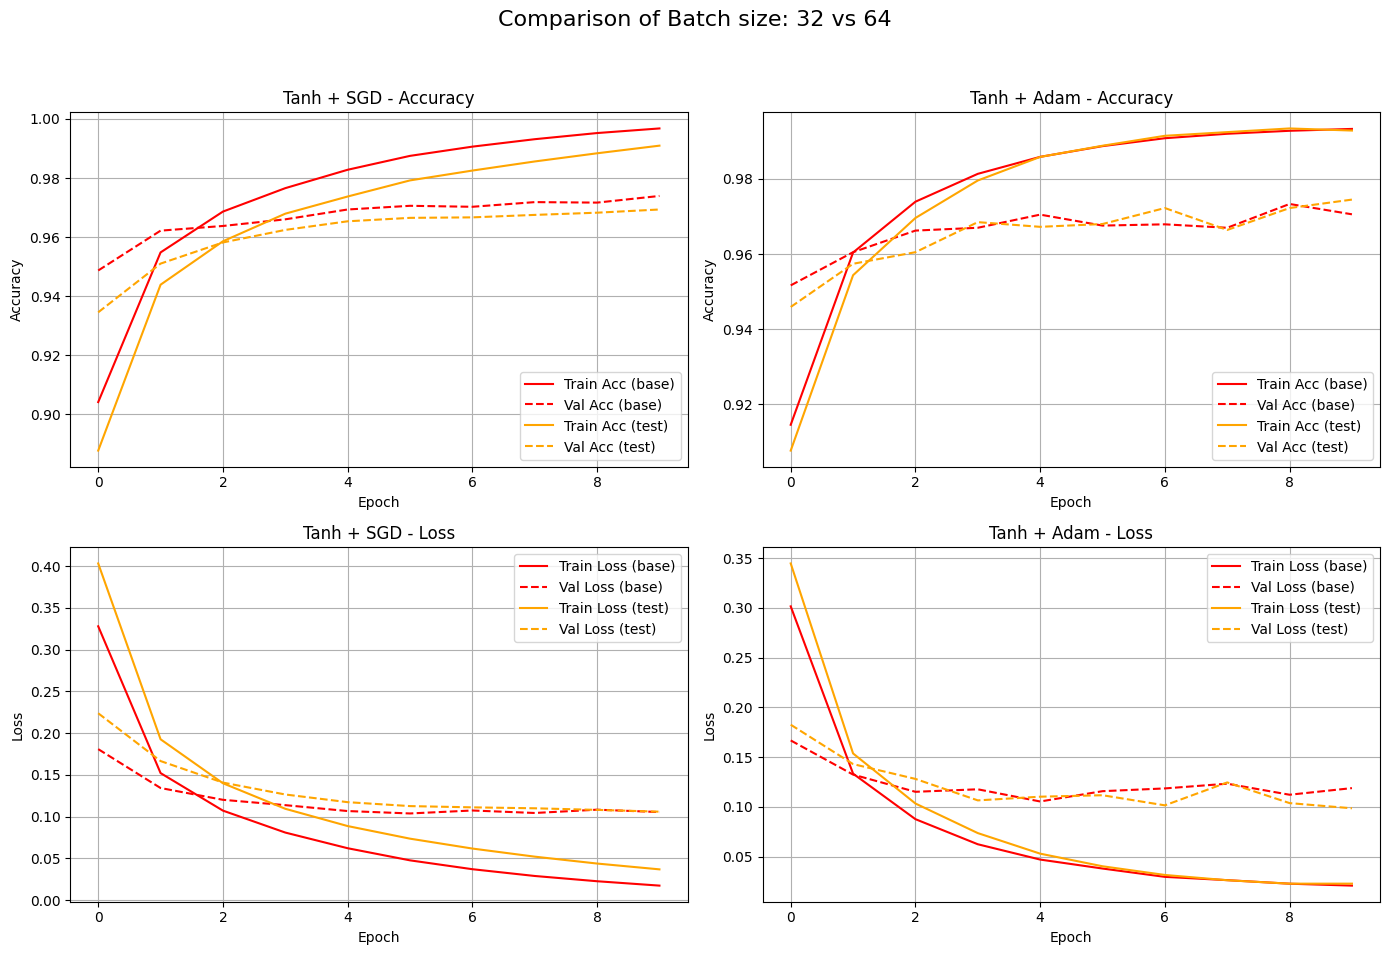

In [25]:
results_t_adjusted_bs = {
    'Tanh + SGD': history_t_sgd_bs.history,
    'Tanh + Adam': history_t_adam_bs.history,
}

plot_model_comparison(
    results_base=results_t_updated,
    results_test=results_t_adjusted_bs,
    model_names=['Tanh + SGD', 'Tanh + Adam'],
    metric_title="Comparison of Batch size: 32 vs 64"
)

#### 6.2.2 Notes

Tanh + SGD
- Batch=32 has better train/val acc and loss compared to batch=64
- Going forward use batch=32 for SGD

Tanh + Adam
- Batch=64 has highest train acc and best train/val loss
- Going forward will use batch=64 for Adam

Both models still show signs of overfitting

### 6.3 Update Base Models
ReLU models:
- SGD will use batch_size=64
- Adam will use batch_size=64

Tanh models:
- SGD will use batch_size=32
- Adam will use batch_size=64

In [26]:
# ReLU
print('act=ReLU, opt=SGD, lr=0.01, bs=64')
history_r_sgd_updated = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=64)

print('\nact=ReLU, opt=Adam, lr=0.001, bs=64')
history_r_adam_updated = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=64)

act=ReLU, opt=SGD, lr=0.01, bs=64
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7497 - loss: 0.8171 - val_accuracy: 0.9373 - val_loss: 0.2044
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.9464 - loss: 0.1772 - val_accuracy: 0.9566 - val_loss: 0.1477
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9645 - loss: 0.1204 - val_accuracy: 0.9607 - val_loss: 0.1302
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9732 - loss: 0.0928 - val_accuracy: 0.9652 - val_loss: 0.1198
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 894us/step - accuracy: 0.9798 - loss: 0.0709 - val_accuracy: 0.9681 - val_loss: 0.1139
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.9844 - loss: 0.0563 - val_accuracy: 0.9693 - val_loss: 0.1134
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9873 - loss: 0.0446 - val_accuracy: 0.9697 - val_loss: 0.1122
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - ac

In [27]:
# Tanh
print('act=Tanh, opt=SGD, lr=0.01, bs=32')
history_t_sgd_updated = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32)

print('\nact=Tanh, opt=Adam, lr=0.001, bs=64')
history_t_adam_updated = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=10, batch_size=64)

act=Tanh, opt=SGD, lr=0.01, bs=32
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - accuracy: 0.8543 - loss: 0.5225 - val_accuracy: 0.9501 - val_loss: 0.1752
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9507 - loss: 0.1657 - val_accuracy: 0.9616 - val_loss: 0.1324
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9666 - loss: 0.1097 - val_accuracy: 0.9645 - val_loss: 0.1192
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9763 - loss: 0.0810 - val_accuracy: 0.9664 - val_loss: 0.1148
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9814 - loss: 0.0631 - val_accuracy: 0.9674 - val_loss: 0.1120
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - accuracy: 0.9862 - loss: 0.0489 - val_accuracy: 0.9692 - val_loss: 0.1075
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9895 - loss: 0.0380 - val_accuracy: 0.9718 - val_loss: 0.1022
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

### 6.4 Plot: Compare ReLU vs Tanh by Optimizers
Now with updated batch_size=64 for ReLU (SGD and Adam) and Tanh (Adam)

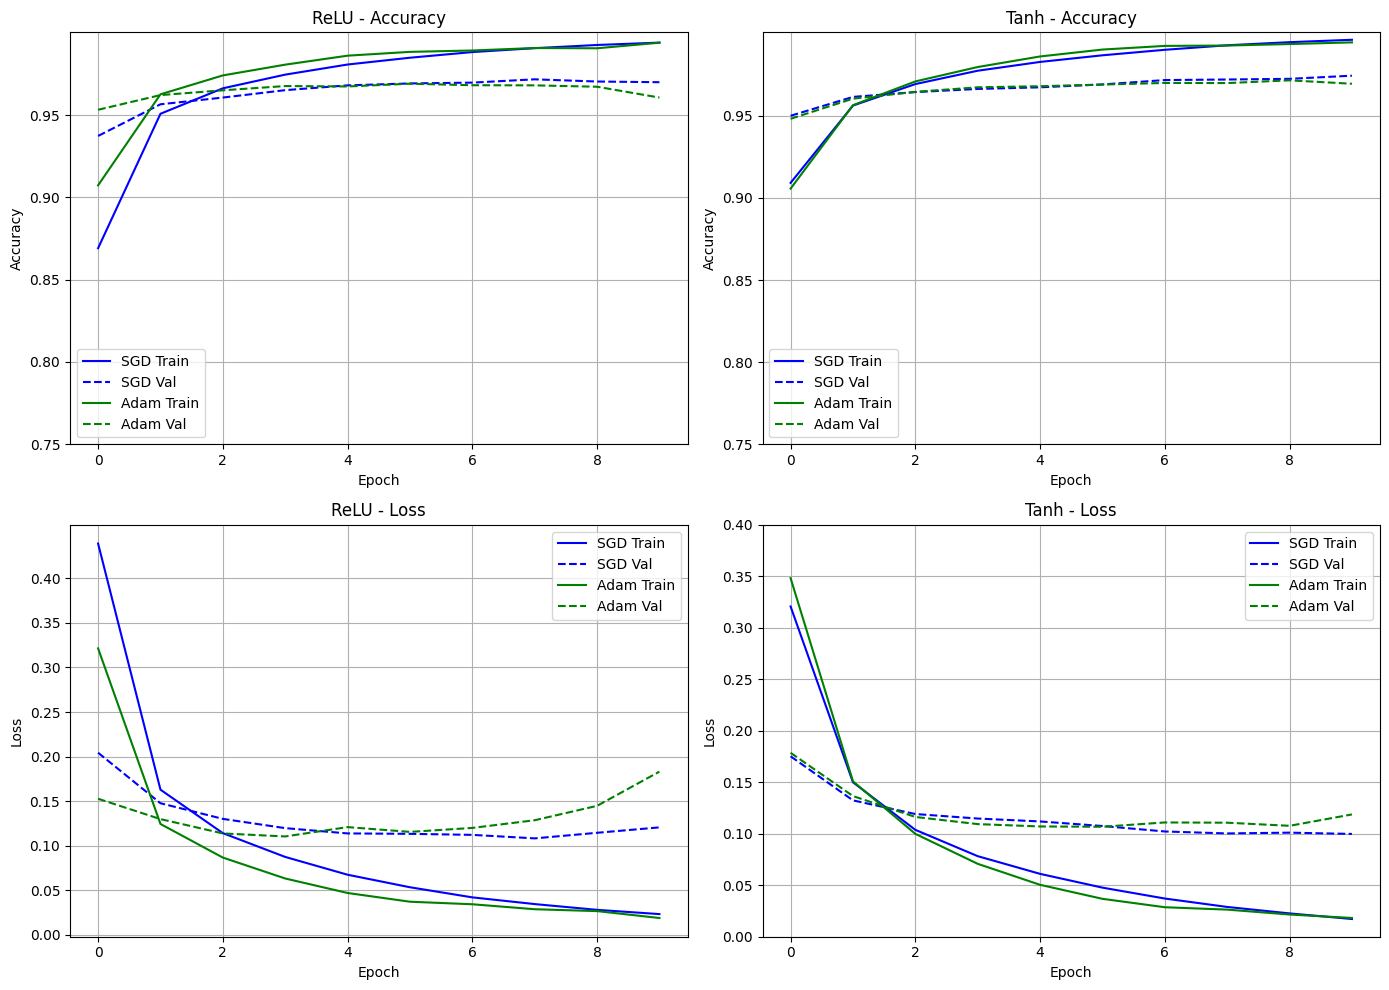

In [28]:
results_r_updated = {
    'ReLU + SGD': history_r_sgd_updated.history,
    'ReLU + Adam': history_r_adam_updated.history,
}

results_t_updated = {
    'Tanh + SGD': history_t_sgd_updated.history,
    'Tanh + Adam': history_t_adam_updated.history,
}

plot_base_comparison(
    history_r_sgd_updated.history,
    history_r_adam_updated.history,
    history_t_sgd_updated.history,
    history_t_adam_updated.history
)

## 7. Adjust num of Epochs + Early Stop

### 7.1. Compare ReLU models with epochs=30/epochs=50 + early stop

In [29]:
# Update ReLU models with epochs=30 + early stop
print('act=ReLU, opt=SGD, lr=0.01, bs=32, epochs=30, earlystop')
history_r_sgd_epoch_30 = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=30, batch_size=64, earlystop=True)

print('\nact=ReLU, opt=Adam, lr=0.001, bs=64 epochs=30, earlystop')
history_r_adam_epoch_30 = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=30, batch_size=64, earlystop=True)

act=ReLU, opt=SGD, lr=0.01, bs=32, epochs=30, earlystop
Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7516 - loss: 0.7784 - val_accuracy: 0.9427 - val_loss: 0.1976
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.9452 - loss: 0.1778 - val_accuracy: 0.9578 - val_loss: 0.1443
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.9624 - loss: 0.1218 - val_accuracy: 0.9617 - val_loss: 0.1291
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step - accuracy: 0.9711 - loss: 0.0935 - val_accuracy: 0.9647 - val_loss: 0.1238
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step - accuracy: 0.9781 - loss: 0.0727 - val_accuracy: 0.9683 - val_loss: 0.1155
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9823 - loss: 0.0588 - val_accuracy: 0.9659 - val_loss: 0.1246
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 907us/step - accuracy: 0.9854 - loss: 0.0485 - val_accuracy: 0.9631 - val_loss: 0.1341
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━

In [30]:
# Update ReLU models with epochs=50 + early stop
print('act=ReLU, opt=SGD, lr=0.01, bs=32, epochs=50, earlystop')
history_r_sgd_epoch_50 = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=50, batch_size=64, earlystop=True)

print('\nact=ReLU, opt=Adam, lr=0.001, bs=64 epochs=50, earlystop')
history_r_adam_epoch_50 = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=50, batch_size=64, earlystop=True)

act=ReLU, opt=SGD, lr=0.01, bs=32, epochs=50, earlystop
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 996us/step - accuracy: 0.7610 - loss: 0.7697 - val_accuracy: 0.9488 - val_loss: 0.1777
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.9476 - loss: 0.1714 - val_accuracy: 0.9596 - val_loss: 0.1395
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step - accuracy: 0.9646 - loss: 0.1165 - val_accuracy: 0.9635 - val_loss: 0.1203
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.9725 - loss: 0.0869 - val_accuracy: 0.9686 - val_loss: 0.1059
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.9795 - loss: 0.0662 - val_accuracy: 0.9707 - val_loss: 0.1026
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.9844 - loss: 0.0517 - val_accuracy: 0.9722 - val_loss: 0.1036
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.9875 - loss: 0.0421 - val_accuracy: 0.9732 - val_loss: 0.1033
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━

#### 7.1.1 Plot: Compare ReLU Number of Epochs (30, 50 + early stop) by Optimizers

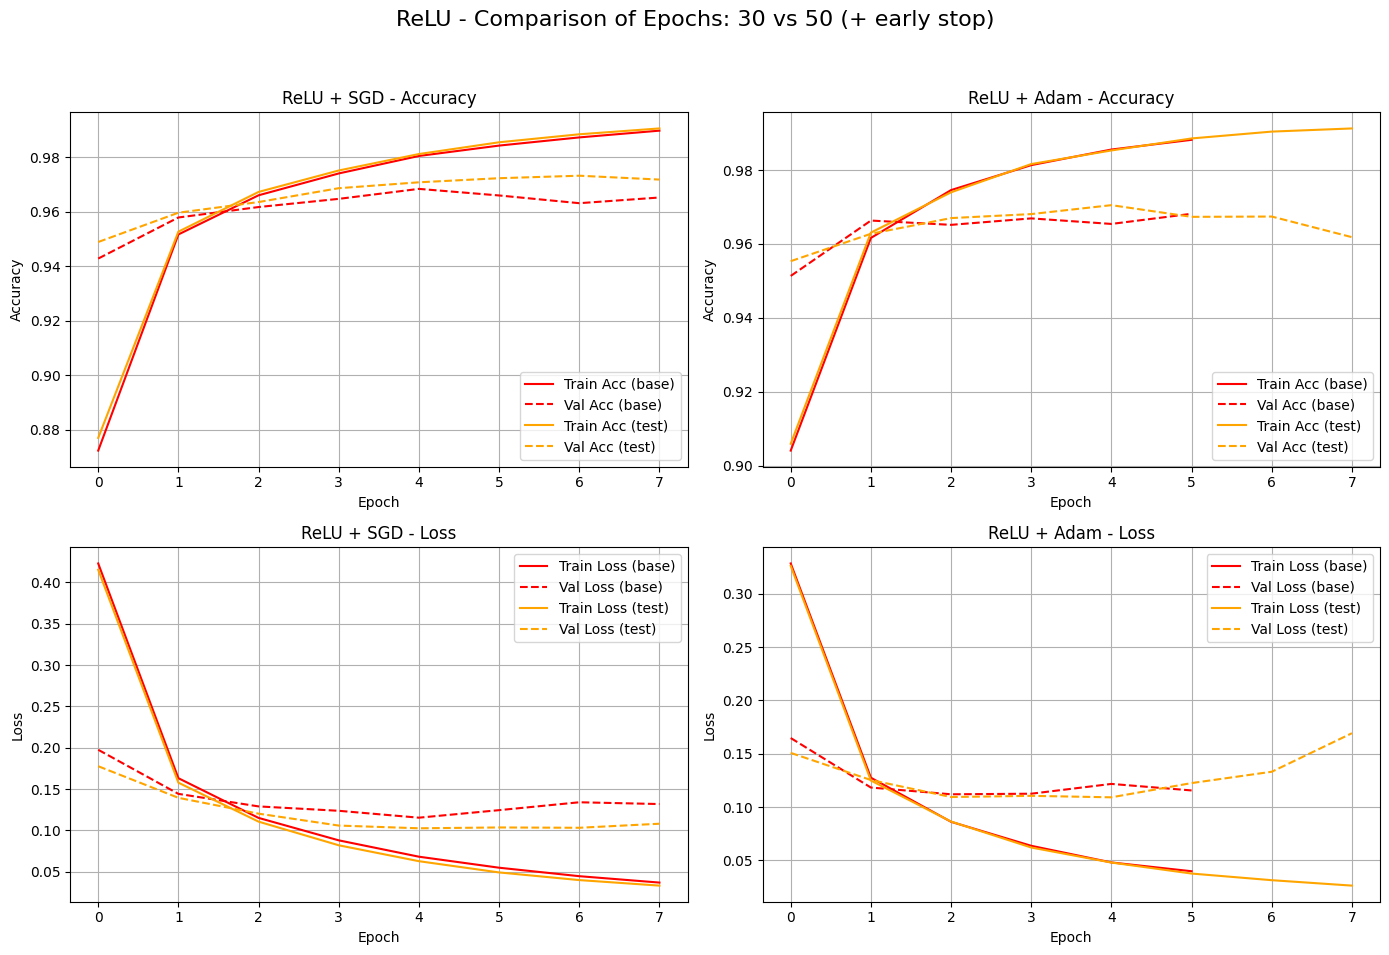

In [31]:
results_r_epoch_30 = {
    'ReLU + SGD': history_r_sgd_epoch_30.history,
    'ReLU + Adam': history_r_adam_epoch_30.history,
}

results_r_epoch_50 = {
    'ReLU + SGD': history_r_sgd_epoch_50.history,
    'ReLU + Adam': history_r_adam_epoch_50.history,
}

plot_model_comparison(
    results_base=results_r_epoch_30,
    results_test=results_r_epoch_50,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="ReLU - Comparison of Epochs: 30 vs 50 (+ early stop)"
)

#### 7.1.2 Notes

Relu + SGD
- improved slightly with epochs=50 with higher final val_accuracy and lower val_loss.
- epochs=50 is more stable toward the end (val_accuracy stays high without dropping significantly), despite the increased training time.
- epochs=30 seems to overfit slightly in later epochs (e.g., epoch 10–11, where val_loss increases even though training accuracy is very high).

ReLU + Adam
- performed better with epochs=50, reaching higher accuracy and lower loss.
- epochs=50 has a smoother decline in val_loss and better generalization.
- epochs=30 plateaued earlier (little improvement after epoch 3–4)

Increasing max epochs to 50 with early stopping did not drastically improve performance but allowed the model to potentially find slightly better minima (better val loss in SGD, slightly better val accuracy).

### 7.2 Compare Tanh models with epochs=30/epochs=50 + early stop

In [32]:
# Update Tanh models with epochs=30 + early stop
print('act=Tanh, opt=SGD, lr=0.01, bs=32, epochs=30')
history_t_sgd_epoch_30 = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=30, batch_size=32, earlystop=True)

print('\nact=Tanh, opt=Adam, lr=0.001, bs=64 epochs=30')
history_t_adam_epoch_30 = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=30, batch_size=64, earlystop=True)

act=Tanh, opt=SGD, lr=0.01, bs=32, epochs=30
Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - accuracy: 0.8400 - loss: 0.5405 - val_accuracy: 0.9456 - val_loss: 0.1833
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step - accuracy: 0.9503 - loss: 0.1672 - val_accuracy: 0.9586 - val_loss: 0.1379
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.9663 - loss: 0.1117 - val_accuracy: 0.9664 - val_loss: 0.1142
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - accuracy: 0.9753 - loss: 0.0837 - val_accuracy: 0.9689 - val_loss: 0.1072
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - accuracy: 0.9808 - loss: 0.0655 - val_accuracy: 0.9707 - val_loss: 0.1012
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.9848 - loss: 0.0515 - val_accuracy: 0.9719 - val_loss: 0.1008
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9892 - loss: 0.0393 - val_accuracy: 0.9728 - val_loss: 0.0969
Epoch 8/30
1500/1500 ━━━━━━━━━━

In [33]:
# Update Tanh models with epochs=50 + early stop
print('act=Tanh, opt=SGD, lr=0.01, bs=32, epochs=50, earlystop')
history_t_sgd_epoch_50 = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=50, batch_size=32, earlystop=True)

print('\nact=Tanh, opt=Adam, lr=0.001, bs=64 epochs=50, earlystop')
history_t_adam_epoch_50 = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=50, batch_size=64, earlystop=True)

act=Tanh, opt=SGD, lr=0.01, bs=32, epochs=50, earlystop
Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step - accuracy: 0.8516 - loss: 0.5180 - val_accuracy: 0.9473 - val_loss: 0.1814
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9514 - loss: 0.1630 - val_accuracy: 0.9590 - val_loss: 0.1409
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9672 - loss: 0.1103 - val_accuracy: 0.9643 - val_loss: 0.1201
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - accuracy: 0.9751 - loss: 0.0829 - val_accuracy: 0.9668 - val_loss: 0.1135
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - accuracy: 0.9818 - loss: 0.0643 - val_accuracy: 0.9663 - val_loss: 0.1139
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - accuracy: 0.9866 - loss: 0.0505 - val_accuracy: 0.9678 - val_loss: 0.1118
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.9897 - loss: 0.0396 - val_accuracy: 0.9701 - val_loss: 0.1070
Epoch 8/50
1500/1500

#### 7.2.1 Plot: Compare Tanh Number of Epochs (30, 50) by Optimizers

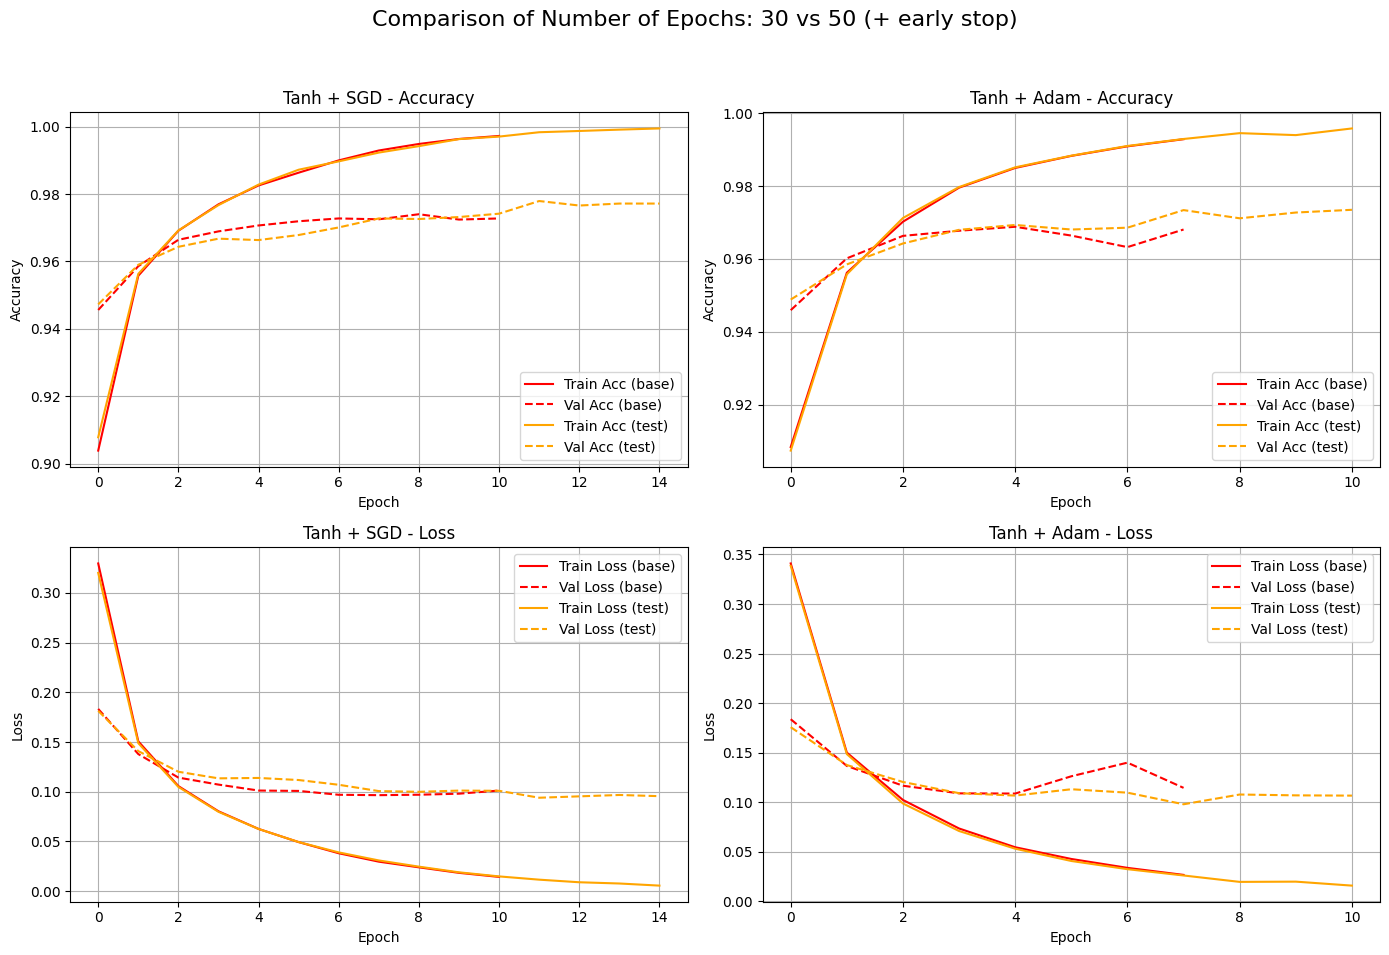

In [34]:
results_t_epoch_30 = {
    'Tanh + SGD': history_t_sgd_epoch_30.history,
    'Tanh + Adam': history_t_adam_epoch_30.history,
}

results_t_epoch_50 = {
    'Tanh + SGD': history_t_sgd_epoch_50.history,
    'Tanh + Adam': history_t_adam_epoch_50.history,
}

plot_model_comparison(
    results_base=results_t_epoch_30,
    results_test=results_t_epoch_50,
    model_names=['Tanh + SGD', 'Tanh + Adam'],
    metric_title="Comparison of Number of Epochs: 30 vs 50 (+ early stop)"
)

#### 7.2.2 Notes 

Tanh + SGD
- best validation accuracy for SGD is essentially the same (~0.9747) in both tests
- best val loss in 30 epochs (0.0917) is slightly lower than in 50 epochs (0.0951), indicating a slightly better fit in the shorter run.

Tanh + Adam
- best accuracy is slightly better in 30 epochs (0.9738) than 50 epochs (0.9721), but difference is marginal.


Both for 30 and 50 epoch max runs, training stopped early around epoch 10–11, meaning the model converged quickly. Setting max epochs to 30 vs 50 did not significantly affect the training outcome.

### 7.3 Compare ReLU Base Model with epochs=50 + early stop

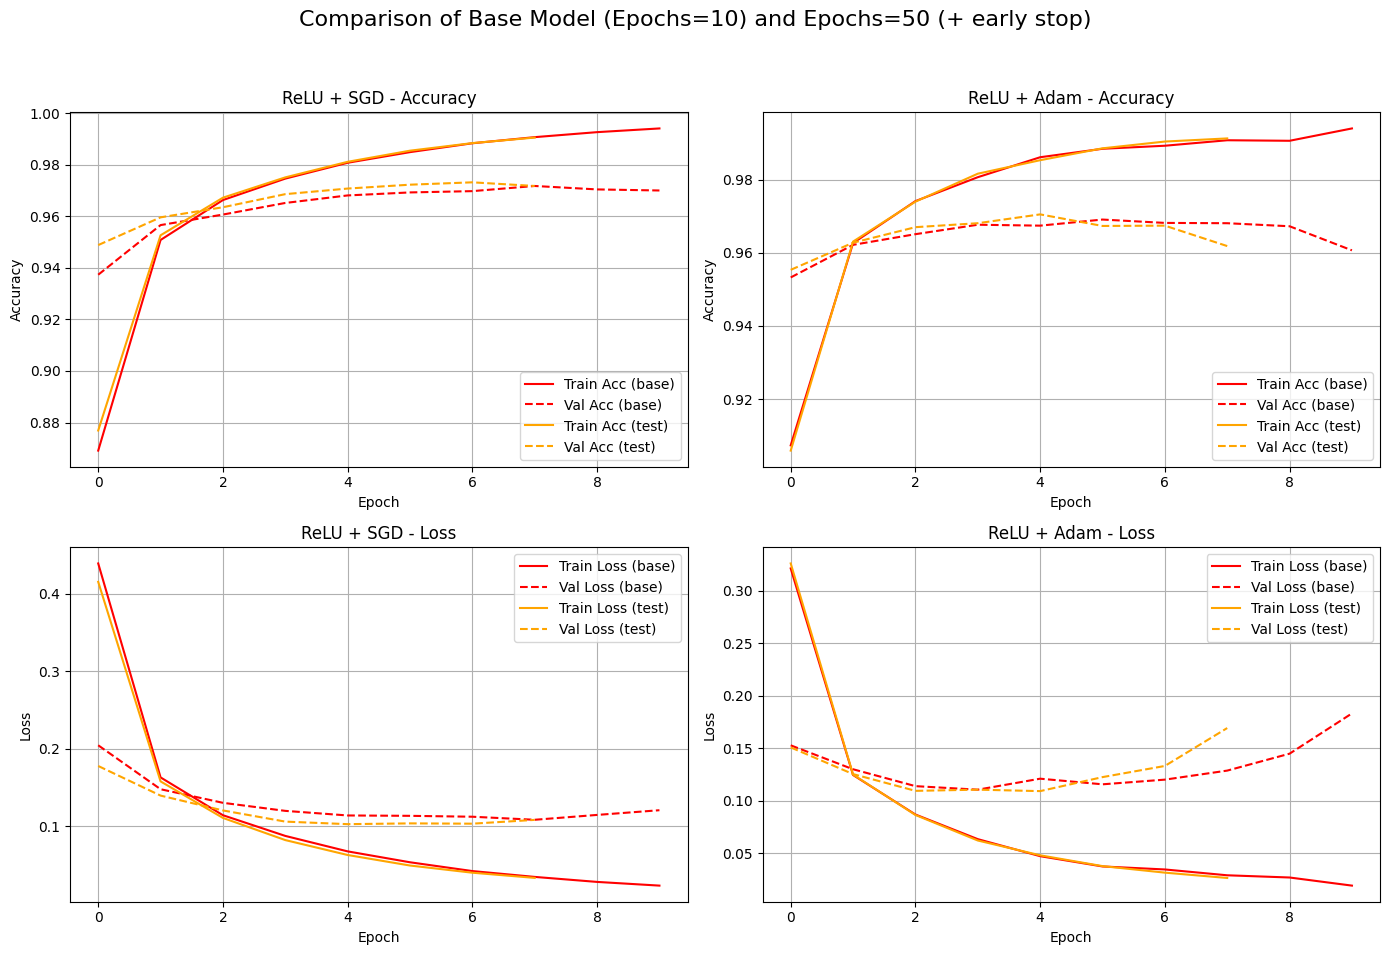

In [35]:
plot_model_comparison(
    results_base=results_r_updated,
    results_test=results_r_epoch_50,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="Comparison of Base Model (Epochs=10) and Epochs=50 (+ early stop)"
)

#### 7.3.1 Notes

Comparing models built with 10 epochs (no early stop) and 50 epochs (early stop), the better model appears to be 10 epochs. For all 4 models above the train and val acc are better, and train and val loss. I will continue using 10 epochs no early stop

## 8. Apply L2 Regularization

### 8.1 Update ReLU models with L2 Regularizers (0.01, 0.001)

In [36]:
# ReLU 
print('act=ReLU, opt=SGD, lr=0.01, epochs=10, bs=64, l2=0.01')
history_r_sgd_l2_01 = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=64, earlystop=False, use_l2=True, l2_rate=0.01)

print('\nact=ReLU, opt=Adam, lr=0.001, epochs=10, bs=64, l2=0.01')
history_r_adam_l2_01 = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=64, earlystop=False, use_l2=True, l2_rate=0.01)

act=ReLU, opt=SGD, lr=0.01, epochs=10, bs=64, l2=0.01
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7293 - loss: 3.0734 - val_accuracy: 0.9159 - val_loss: 0.7745
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.9173 - loss: 0.6951 - val_accuracy: 0.9316 - val_loss: 0.5541
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.9314 - loss: 0.5453 - val_accuracy: 0.9359 - val_loss: 0.5101
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - accuracy: 0.9377 - loss: 0.5042 - val_accuracy: 0.9388 - val_loss: 0.4884
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 982us/step - accuracy: 0.9420 - loss: 0.4799 - val_accuracy: 0.9415 - val_loss: 0.4696
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.9436 - loss: 0.4631 - val_accuracy: 0.9439 - val_loss: 0.4579
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9464 - loss: 0.4500 - val_accuracy: 0.9452 - val_loss: 0.4488
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 

In [37]:
# ReLU 
print('act=ReLU, opt=SGD, lr=0.01, epochs=10, bs=64, l2=0.001')
history_r_sgd_l2_001 = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=64, earlystop=False, use_l2=True, l2_rate=0.001)

print('\nact=ReLU, opt=Adam, lr=0.001, epochs=10, bs=64, l2=0.001')
history_r_adam_l2_001 = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=64, earlystop=False, use_l2=True, l2_rate=0.001)

act=ReLU, opt=SGD, lr=0.01, epochs=10, bs=64, l2=0.001
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7394 - loss: 1.2125 - val_accuracy: 0.9413 - val_loss: 0.5065
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.9449 - loss: 0.4766 - val_accuracy: 0.9550 - val_loss: 0.4079
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 994us/step - accuracy: 0.9622 - loss: 0.3720 - val_accuracy: 0.9629 - val_loss: 0.3415
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step - accuracy: 0.9703 - loss: 0.3077 - val_accuracy: 0.9640 - val_loss: 0.3033
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.9750 - loss: 0.2632 - val_accuracy: 0.9657 - val_loss: 0.2762
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.9784 - loss: 0.2312 - val_accuracy: 0.9686 - val_loss: 0.2489
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.9806 - loss: 0.2074 - val_accuracy: 0.9715 - val_loss: 0.2299
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━

#### 8.1.1 Plot: Compare ReLU L2 regularizer rates (0.01, 0.001)

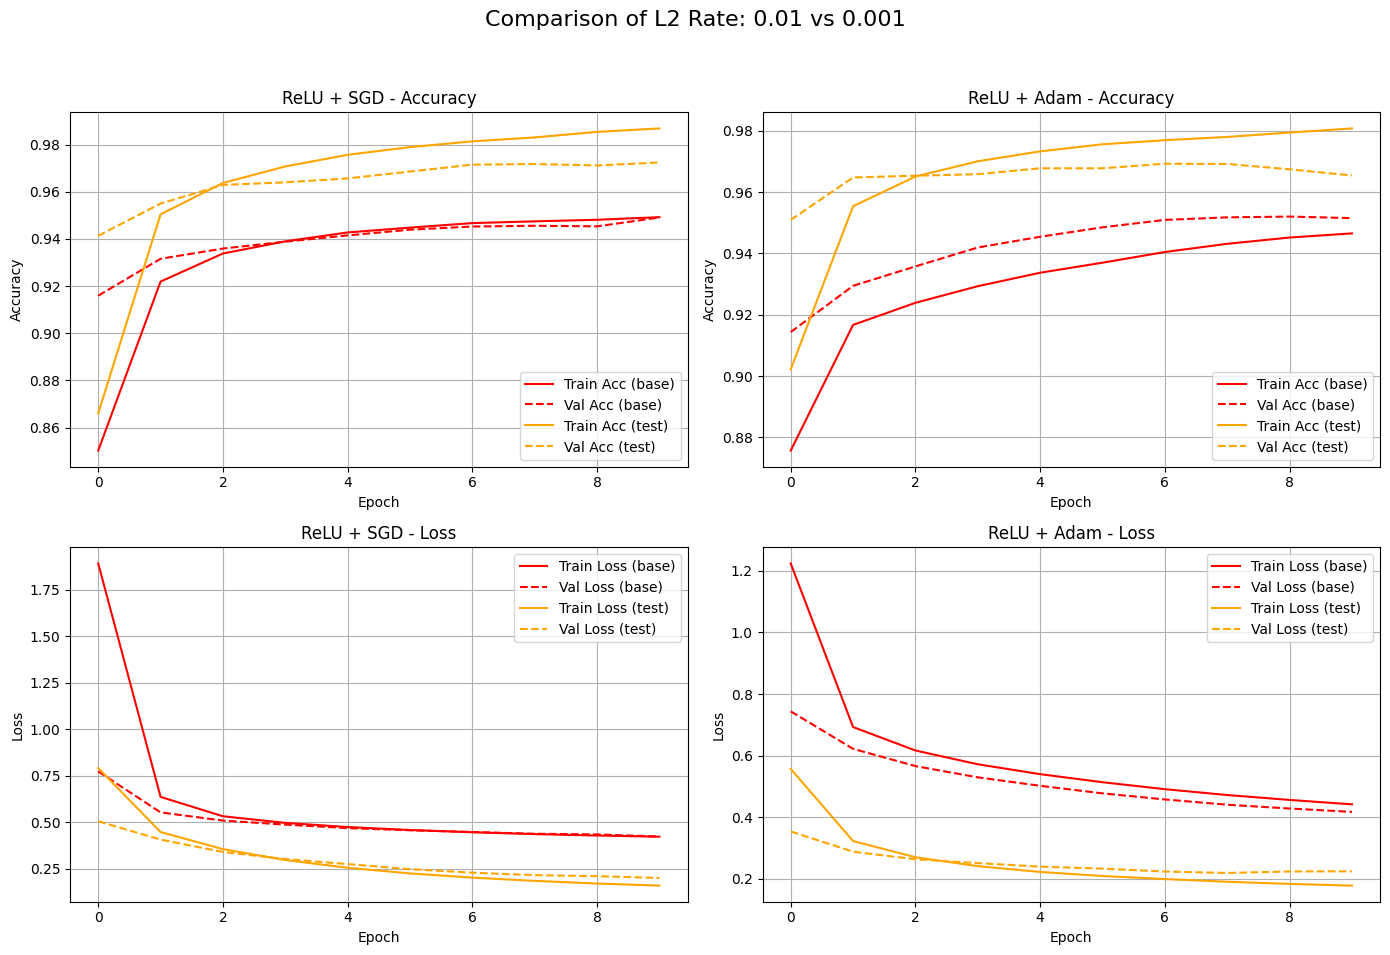

In [38]:
results_r_l2_01 = {
    'ReLU + SGD': history_r_sgd_l2_01.history,
    'ReLU + Adam': history_r_adam_l2_01.history,
}

results_r_l2_001 = {
    'ReLU + SGD': history_r_sgd_l2_001.history,
    'ReLU + Adam': history_r_adam_l2_001.history,
}

plot_model_comparison(
    results_base=results_r_l2_01,
    results_test=results_r_l2_001,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="Comparison of L2 Rate: 0.01 vs 0.001"
)

#### 8.1.2 ReLU: Apply early stop to best L2 model

In [39]:
# apply l2 with earlystop
print('act=ReLU, opt=SGD, lr=0.01, epochs=10, bs=64, l2=0.001, early stop')
history_r_sgd_l2_001_earlystop = train_model(activation='relu', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=64, earlystop=True, use_l2=True, l2_rate=0.001)

print('\nact=ReLU, opt=Adam, lr=0.001, epochs=10, bs=64, l2=0.001, early stop')
history_r_adam_l2_001_earlystop = train_model(activation='relu', optimizer=Adam, lr=0.001, epochs=10, batch_size=64, earlystop=True, use_l2=True, l2_rate=0.001)

act=ReLU, opt=SGD, lr=0.01, epochs=10, bs=64, l2=0.001, early stop
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7628 - loss: 1.1252 - val_accuracy: 0.9383 - val_loss: 0.5117
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9455 - loss: 0.4714 - val_accuracy: 0.9569 - val_loss: 0.3937
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9613 - loss: 0.3693 - val_accuracy: 0.9647 - val_loss: 0.3329
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9704 - loss: 0.3061 - val_accuracy: 0.9679 - val_loss: 0.2897
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.9767 - loss: 0.2618 - val_accuracy: 0.9706 - val_loss: 0.2591
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.9796 - loss: 0.2294 - val_accuracy: 0.9725 - val_loss: 0.2372
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.9816 - loss: 0.2060 - val_accuracy: 0.9732 - val_loss: 0.2216
Epoch 8/10
750/750 ━━━━━━━━━━━━

#### 8.1.3 Plot: Compare ReLU l2=0.001 with and without early stop

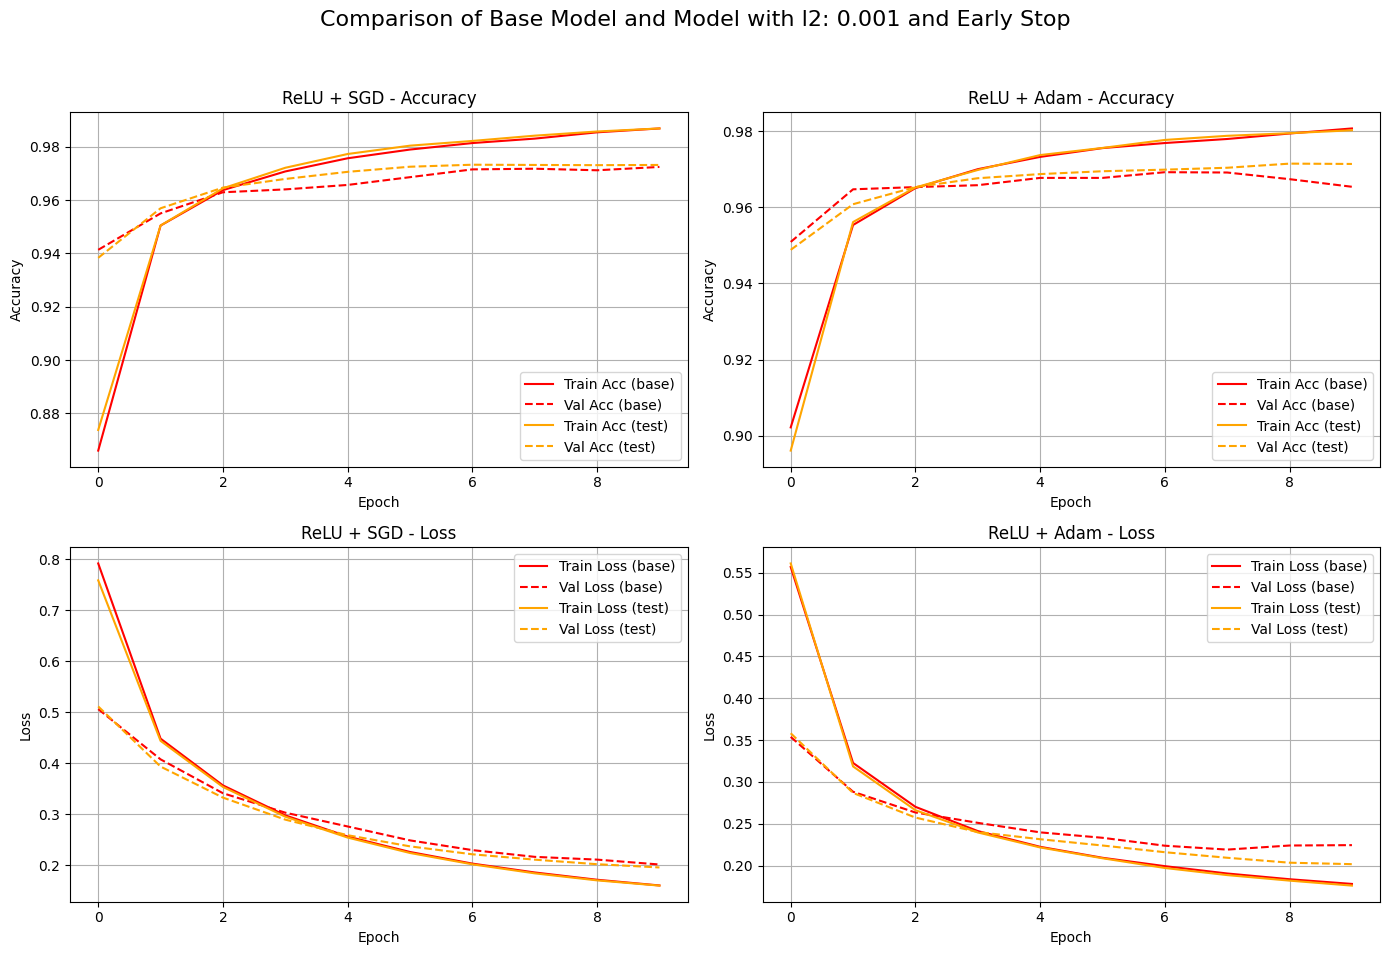

In [40]:
results_r_l2_001_earlystop = {
    'ReLU + SGD': history_r_sgd_l2_001_earlystop.history,
    'ReLU + Adam': history_r_adam_l2_001_earlystop.history,
}

plot_model_comparison(
    results_base=results_r_l2_001,
    results_test=results_r_l2_001_earlystop,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="Comparison of Base Model and Model with l2: 0.001 and Early Stop"
)

#### 8.1.4 Plot: Compare ReLU Base Model with L2=0.001

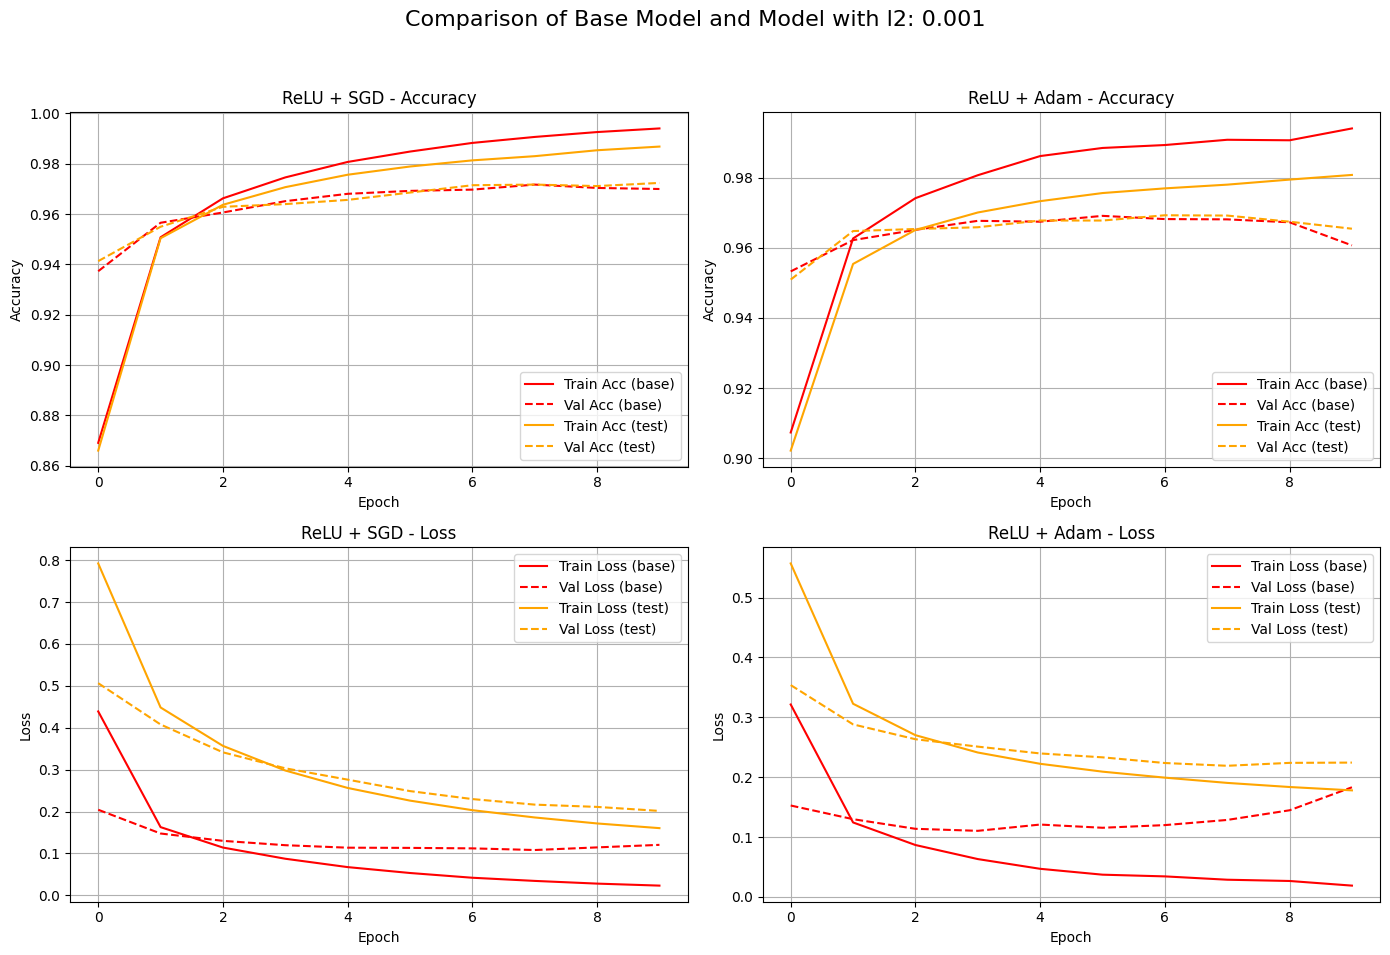

In [41]:
plot_model_comparison(
    results_base=results_r_updated,
    results_test=results_r_l2_001,
    model_names=['ReLU + SGD', 'ReLU + Adam'],
    metric_title="Comparison of Base Model and Model with l2: 0.001"
)

#### 8.1.5 Notes

L2 Regularization Alone (No Early Stop):
- Lets the model train longer, and continue improving beyond where early stopping would have cut off.
- Works best when overfitting is mild or well-controlled, as seems to be the case here.
- Val loss is more stable over time, or at least doesn’t sharply increase, so there's no penalty for allowing full training.

Early Stopping Alone:
- Good for fast, robust training where compute is a constraint or if overfitting happens rapidly.
- But might cut training too early, leaving generalization performance slightly below what L2 can achieve with full epochs.

Val accuracy improves consistently through 20 epochs when using L2 only, especially with SGD. That indicates early stopping was too aggressive in Set 1, which is probably triggered by noise or local plateaus.

### 8.2 Update Tanh models with L2 Regularizers (0.01, 0.001)

In [42]:
# Tanh 
print('act=Tanh, opt=SGD, lr=0.01, epochs=10, bs=32, l2=0.01')
history_t_sgd_l2_01 = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32, earlystop=False, use_l2=True, l2_rate=0.01)

print('\nact=Tanh, opt=Adam, lr=0.001, epochs=10, bs=64, l2=0.01')
history_t_adam_l2_01 = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=10, batch_size=64, earlystop=False, use_l2=True, l2_rate=0.01)

act=Tanh, opt=SGD, lr=0.01, epochs=10, bs=32, l2=0.01
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - accuracy: 0.8349 - loss: 2.1847 - val_accuracy: 0.8952 - val_loss: 0.6240
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - accuracy: 0.8964 - loss: 0.6105 - val_accuracy: 0.9091 - val_loss: 0.5564
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.9036 - loss: 0.5688 - val_accuracy: 0.9138 - val_loss: 0.5273
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - accuracy: 0.9057 - loss: 0.5507 - val_accuracy: 0.9138 - val_loss: 0.5166
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step - accuracy: 0.9075 - loss: 0.5399 - val_accuracy: 0.9147 - val_loss: 0.5118
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - accuracy: 0.9081 - loss: 0.5333 - val_accuracy: 0.9131 - val_loss: 0.5093
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - accuracy: 0.9081 - loss: 0.5293 - val_accuracy: 0.9125 - val_loss: 0.5072
Epoch 8/10
1500/1500 ━

In [43]:
# Tanh 
print('act=Tanh, opt=SGD, lr=0.01, epochs=10, bs=32, l2=0.001')
history_t_sgd_l2_001 = train_model(activation='tanh', optimizer=SGD, momentum=0.9, lr=0.01, epochs=10, batch_size=32, earlystop=False, use_l2=True, l2_rate=0.001)

print('\nact=Tanh, opt=Adam, lr=0.001, epochs=10, bs=64, l2=0.001')
history_t_adam_l2_001 = train_model(activation='tanh', optimizer=Adam, lr=0.001, epochs=10, batch_size=64, earlystop=False, use_l2=True, l2_rate=0.001)

act=Tanh, opt=SGD, lr=0.01, epochs=10, bs=32, l2=0.001
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 942us/step - accuracy: 0.8506 - loss: 0.8632 - val_accuracy: 0.9437 - val_loss: 0.4501
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - accuracy: 0.9437 - loss: 0.4211 - val_accuracy: 0.9564 - val_loss: 0.3362
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.9552 - loss: 0.3210 - val_accuracy: 0.9610 - val_loss: 0.2820
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.9625 - loss: 0.2685 - val_accuracy: 0.9636 - val_loss: 0.2527
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 997us/step - accuracy: 0.9666 - loss: 0.2391 - val_accuracy: 0.9658 - val_loss: 0.2362
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9685 - loss: 0.2220 - val_accuracy: 0.9668 - val_loss: 0.2272
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9698 - loss: 0.2113 - val_accuracy: 0.9669 - val_loss: 0.2229
Epoch 8/10
1500/1500 ━━━━

#### 8.2.1 Plot: Compare Tanh L2 regularizer rates (0.01, 0.001)

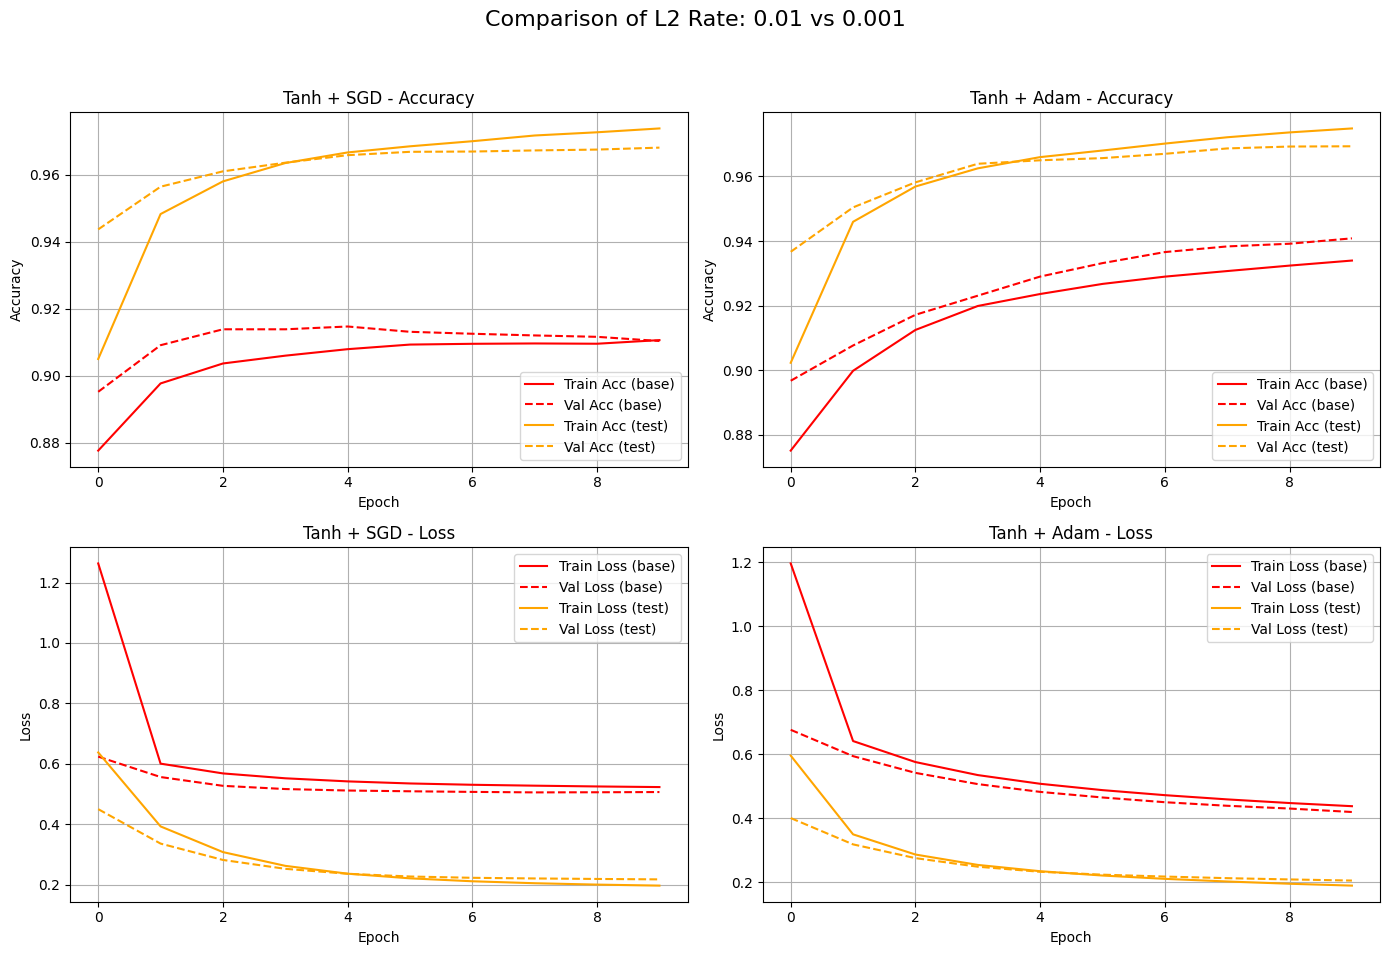

In [44]:
results_t_l2_01 = {
    'Tanh + SGD': history_t_sgd_l2_01.history,
    'Tanh + Adam': history_t_adam_l2_01.history,
}

results_t_l2_001 = {
    'Tanh + SGD': history_t_sgd_l2_001.history,
    'Tanh + Adam': history_t_adam_l2_001.history,
}

plot_model_comparison(
    results_base=results_t_l2_01,
    results_test=results_t_l2_001,
    model_names=['Tanh + SGD', 'Tanh + Adam'],
    metric_title="Comparison of L2 Rate: 0.01 vs 0.001"
)

## 9. Final Eval

In [45]:
# Final evaluation on held-out test set
model = build_model(activation='relu')
opt = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train_flat, y_train_cat, epochs=10, batch_size=64, verbose=0)
loss, acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"Best model (ReLU + SGD): Test accuracy = {acc:.4f}, Test loss = {loss:.4f}")

Best model (ReLU + SGD): Test accuracy = 0.9718, Test loss = 0.1023
